## Load the dataset

In [14]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import kagglehub
import pandas as pd
import seaborn as sns
import numpy as np
from nltk.corpus import stopwords
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import nltk
nltk.download('all')
# Download latest version
file_name = 'IMDB Dataset.csv'
path = Path.cwd().resolve()
IMDB_DATA = path / "data" / file_name
df = pd.read_csv(IMDB_DATA)
df.head()

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\kofia\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\kofia\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\kofia\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\kofia\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\kofia\AppData\Roaming\nltk_data...
[

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [15]:
import torch


is_cuda = torch.cuda.is_available()

if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device('cpu')
    print("GPU not available, CPU used")

GPU is available


## Exploratory Data Analysis

Train data shape: (37500,)
Test data shape: (12500,)


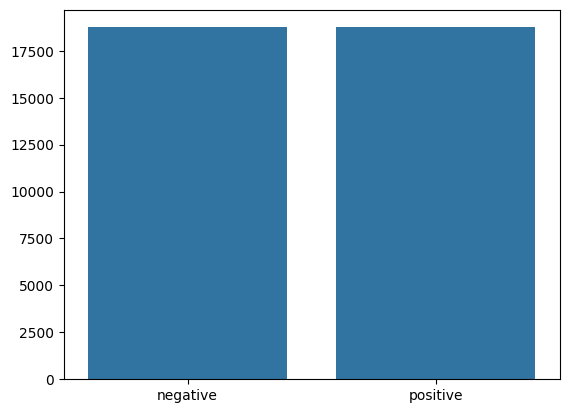

In [16]:
from matplotlib import pyplot as plt


X = df['review'].to_numpy()
y = df['sentiment'].to_numpy()

# X, y = df['review'].values,df['sentiment'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)
print(f'Train data shape: {X_train.shape}')
print(f'Test data shape: {X_test.shape}')

dd = pd.Series(y_train).value_counts()
sns.barplot(x=np.array(['negative', 'positive']), y=dd.values)
plt.show()

## Text Preprocessing

In [17]:
from collections import Counter
import re


def preprocess_string(s):
    #remove all none-word characters (all except numbers and letters)
    s = re.sub(r"[^\w\s]", '', s)
    # Replace all runs of whitespaces with no space
    s = re.sub(r"\s+", '', s)
    #replace digits with no space
    s = re.sub(r"/d", '', s)
    return s


def tokenize(X_train, y_train, x_val, y_val):
    word_list = []
    
    stop_words = set(stopwords.words('english'))
    for sent in X_train:
        for word in sent.lower().split():
            word = preprocess_string(word)
            if word not in stop_words and word != '':
                word_list.append(word)
                
    corpus = Counter(word_list)
    #sorting based on most common words
    corpus_ = sorted(corpus, key=corpus.get, reverse=True)[:1000]
    onehot_dict = {w:i+1 for i, w in enumerate(corpus_)}
    # print(onehot_dict)
    final_list_train, final_list_test = [], []
    for sent in X_train:
        final_list_train.append([onehot_dict[preprocess_string(word)] for word in sent.lower().split()
                                 if preprocess_string(word) in onehot_dict.keys()])
    for sent in x_val:
        final_list_test.append([onehot_dict[preprocess_string(word)] for word in sent.lower().split()
                                if preprocess_string(word) in onehot_dict.keys()])
        
    encoded_train = [1 if label =='positive' else 0 for label in y_train]
    encoded_test = [1 if label =='positive' else 0 for label in y_val]
    return np.array(final_list_train, dtype=object), np.array(encoded_train), np.array(final_list_test, dtype=object), np.array(encoded_test), onehot_dict


X_train, y_train, X_test, y_test, vocab = tokenize(X_train, y_train, X_test, y_test)

<Axes: >

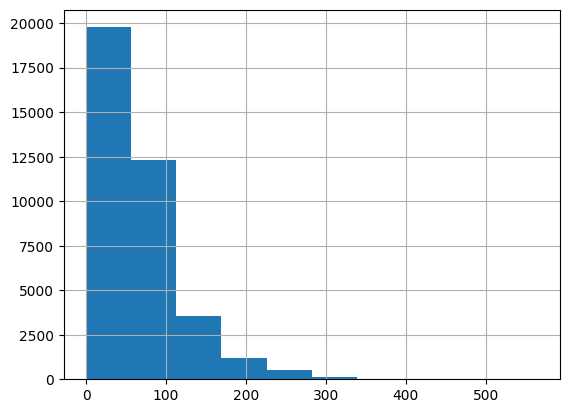

In [18]:
rev_len = [len(i) for i in X_train]
pd.Series(rev_len).hist()

## Preparing the data for the model

In [19]:
def padding_(sentences, seq_len):
    features = np.zeros((len(sentences), seq_len), dtype=int)
    for ii, review in enumerate(sentences):
        if len(review) != 0:
            features[ii, -len(review):] = np.array(review)[:seq_len]
    return features

X_train_pad = padding_(X_train, 500)
X_test_pad = padding_(X_test, 500)

In [20]:
#create tensor datasets
train_data = TensorDataset(torch.from_numpy(X_train_pad), torch.from_numpy(y_train))
valid_data = TensorDataset(torch.from_numpy(X_test_pad), torch.from_numpy(y_test))

batch_size = 50

train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size)
valid_loader = DataLoader(valid_data, shuffle=True, batch_size=batch_size)

dataiter = iter(train_loader)
sample_x, sample_y = next(dataiter)

print('Sample input size: ', sample_x.size()) #batch_size, seq_length
print('Sample input: \n', sample_x)
print('Sample output: \n', sample_y)

Sample input size:  torch.Size([50, 500])
Sample input: 
 tensor([[  0,   0,   0,  ...,  41, 537, 302],
        [  0,   0,   0,  ..., 151,   6,  25],
        [  0,   0,   0,  ..., 505, 734, 372],
        ...,
        [  0,   0,   0,  ...,  16,   3, 408],
        [  0,   0,   0,  ..., 380, 289, 195],
        [  0,   0,   0,  ...,  70,  52,  45]])
Sample output: 
 tensor([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1,
        0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
        1, 0])


In [21]:
class SentimentRNN(nn.Module):
    def __init__(self, no_layers, vocab_size, hidden_dim, embedding_dim, output_dim, drop_prob=0.5):
        super(SentimentRNN,self).__init__()
        
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        
        self.no_layers = no_layers
        self.vocab_size = vocab_size
        
        #embedding and lstm layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        #lstm
        self.lstm = nn.LSTM(input_size=embedding_dim, hidden_size=self.hidden_dim, num_layers=no_layers, batch_first=True)
        
        #dropout layer
        self.dropout = nn.Dropout(0.3)
        
        #linear and sigmoid layer
        self.fc = nn.Linear(self.hidden_dim, output_dim)
        self.sig = nn.Sigmoid()
    
    def forward(self, x, hidden):
        batch_size = x.size(0)
        #embeddings and lstm_out
        
        embeds = self.embedding(x)
        #print(embeds.shape)
        lstm_out, hidden = self.lstm(embeds, hidden)
        
        lstm_out = lstm_out.contiguous().view(-1, self.hidden_dim)
        
        #dropout and fully connected layer
        out = self.dropout(lstm_out)
        out = self.fc(out)
        
        #sigmoid function
        sig_out = self.sig(out)
        
        #reshape to be batch_size first
        sig_out = sig_out.view(batch_size, -1)
        
        #get last batch of labels
        sig_out = sig_out[:, -1]
        
        #return last sigmoid output and hidden state
        return sig_out, hidden
        
           
    def init_hidden(self, batch_size):
        ''' Initializes hidden state '''
        # Create two new tensors with sizes n_layers x batch_size x hidden_dim,
        # initialized to zero, for hidden state and cell state of LSTM
        h0 = torch.zeros((self.no_layers,batch_size,self.hidden_dim)).to(device)
        c0 = torch.zeros((self.no_layers,batch_size,self.hidden_dim)).to(device)
        hidden = (h0,c0)
        return hidden

In [22]:
no_layers = 2
vocab_size = len(vocab) + 1 #extra 1 for padding
embedding_dim = 64
output_dim = 1
hidden_dim = 256

model = SentimentRNN(no_layers, vocab_size, hidden_dim, embedding_dim, output_dim, drop_prob=0.5)

#moving to gpi 
model.to(device)
print(model)

SentimentRNN(
  (embedding): Embedding(1001, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sig): Sigmoid()
)


In [23]:
#loss and optimization functions

lr=0.001

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#function to predict accuracy
def acc(pred, label):
    pred = torch.round(pred.squeeze())
    return torch.sum(pred == label.squeeze()).item()

In [25]:
clip = 5
epochs = 5
valid_loss_min = np.inf
# train for some number of epochs
epoch_tr_loss,epoch_vl_loss = [],[]
epoch_tr_acc,epoch_vl_acc = [],[]


for epoch in range(epochs):
    train_losses = []
    train_acc = 0.0
    model.train()
    # initialize hidden state
    h = model.init_hidden(batch_size)
    for inputs, labels in train_loader:
       
        inputs, labels = inputs.to(device), labels.to(device)  
        # Creating new variables for the hidden state, otherwise
        # we'd backprop through the entire training history
        h = tuple([each.data for each in h])
       
        model.zero_grad()
        output,h = model(inputs,h)
       
        # calculate the loss and perform backprop
        loss = criterion(output.squeeze(), labels.float())
        loss.backward()
        train_losses.append(loss.item())
        # calculating accuracy
        accuracy = acc(output,labels)
        train_acc += accuracy
        #`clip_grad_norm` helps prevent the exploding gradient problem in RNNs / LSTMs.
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
       
    val_h = model.init_hidden(batch_size)
    val_losses = []
    val_acc = 0.0
    model.eval()
    for inputs, labels in valid_loader:
            val_h = tuple([each.data for each in val_h])


            inputs, labels = inputs.to(device), labels.to(device)


            output, val_h = model(inputs, val_h)
            val_loss = criterion(output.squeeze(), labels.float())


            val_losses.append(val_loss.item())
           
            accuracy = acc(output,labels)
            val_acc += accuracy
           
    epoch_train_loss = np.mean(train_losses)
    epoch_val_loss = np.mean(val_losses)
    epoch_train_acc = train_acc/len(train_loader.dataset)
    epoch_val_acc = val_acc/len(valid_loader.dataset)
    epoch_tr_loss.append(epoch_train_loss)
    epoch_vl_loss.append(epoch_val_loss)
    epoch_tr_acc.append(epoch_train_acc)
    epoch_vl_acc.append(epoch_val_acc)
    print(f'Epoch {epoch+1}')
    print(f'train_loss : {epoch_train_loss} val_loss : {epoch_val_loss}')
    print(f'train_accuracy : {epoch_train_acc*100} val_accuracy : {epoch_val_acc*100}')
    if epoch_val_loss <= valid_loss_min:
        torch.save(model.state_dict(), 'state_dict.pt')
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min,epoch_val_loss))
        valid_loss_min = epoch_val_loss
    print(25*'==')

Epoch 1
train_loss : 0.5663181264003118 val_loss : 0.44012256181240084
train_accuracy : 69.84266666666666 val_accuracy : 80.42399999999999
Validation loss decreased (inf --> 0.440123).  Saving model ...
Epoch 2
train_loss : 0.3920126085281372 val_loss : 0.361269738137722
train_accuracy : 83.03733333333334 val_accuracy : 84.152
Validation loss decreased (0.440123 --> 0.361270).  Saving model ...
Epoch 3
train_loss : 0.3336981091002623 val_loss : 0.34848281407356263
train_accuracy : 85.856 val_accuracy : 85.512
Validation loss decreased (0.361270 --> 0.348483).  Saving model ...
Epoch 4
train_loss : 0.30115909284353254 val_loss : 0.31540762388706206
train_accuracy : 87.54933333333334 val_accuracy : 86.47200000000001
Validation loss decreased (0.348483 --> 0.315408).  Saving model ...
Epoch 5
train_loss : 0.2709565493861834 val_loss : 0.32162475103139876
train_accuracy : 88.832 val_accuracy : 86.19200000000001


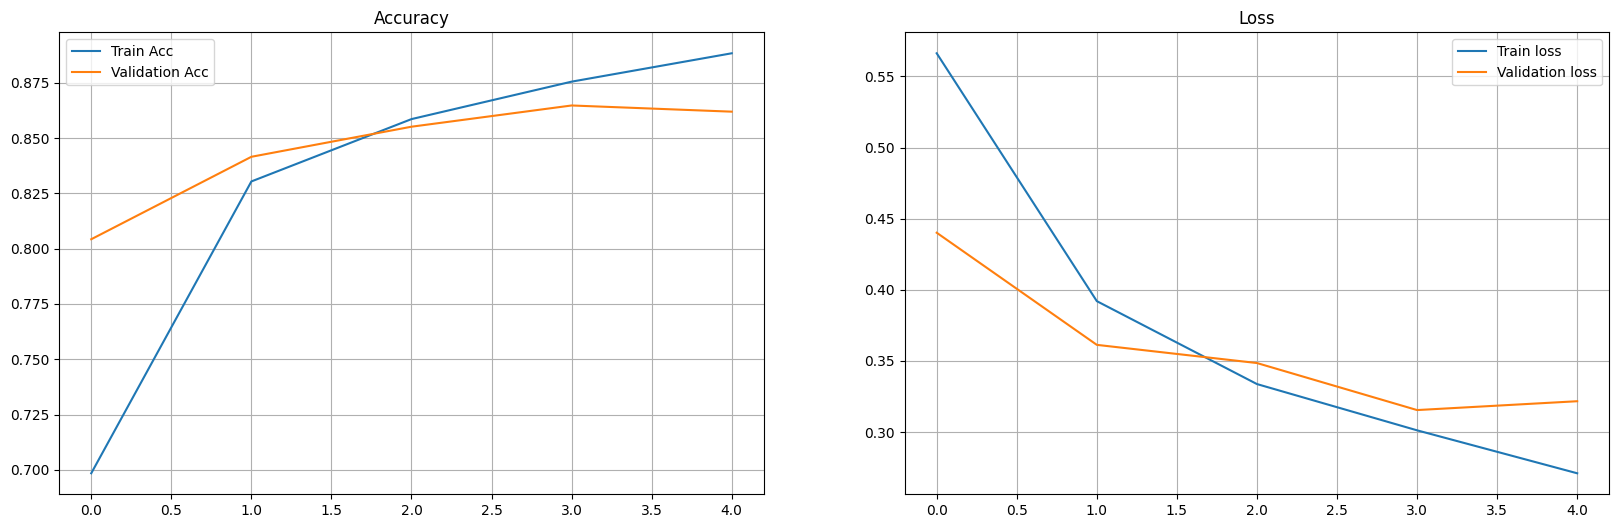

In [26]:
fig = plt.figure(figsize = (20, 6))
plt.subplot(1, 2, 1)
plt.plot(epoch_tr_acc, label='Train Acc')
plt.plot(epoch_vl_acc, label='Validation Acc')
plt.title("Accuracy")
plt.legend()
plt.grid()
   
plt.subplot(1, 2, 2)
plt.plot(epoch_tr_loss, label='Train loss')
plt.plot(epoch_vl_loss, label='Validation loss')
plt.title("Loss")
plt.legend()
plt.grid()


plt.show()


In [27]:
def predict_text(text):
    word_seq = np.array([vocab[preprocess_string(word)] for word in text.split() if preprocess_string(word) in vocab.keys()])
    word_seq = np.expand_dims(word_seq, axis=0)
    pad = torch.from_numpy(padding_(word_seq, 500))
    inputs = pad.to(device)
    batch_size = 1
    h = model.init_hidden(batch_size)
    h = tuple([each.data for each in h])
    output, h = model(inputs, h)
    return(output.item())


index = 30
print(df['review'][index])
print('='*70)
print(f'Actual sentiment is  : {df["sentiment"][index]}')
print('='*70)
pro = predict_text(df['review'][index])
status = "positive" if pro > 0.5 else "negative"
pro = (1 - pro) if status == "negative" else pro
print(f'Predicted sentiment is {status} with a probability of {pro}')

Taut and organically gripping, Edward Dmytryk's Crossfire is a distinctive suspense thriller, an unlikely "message" movie using the look and devices of the noir cycle.<br /><br />Bivouacked in Washington, DC, a company of soldiers cope with their restlessness by hanging out in bars. Three of them end up at a stranger's apartment where Robert Ryan, drunk and belligerent, beats their host (Sam Levene) to death because he happens to be Jewish. Police detective Robert Young investigates with the help of Robert Mitchum, who's assigned to Ryan's outfit. Suspicion falls on the second of the three (George Cooper), who has vanished. Ryan slays the third buddy (Steve Brodie) to insure his silence before Young closes in.<br /><br />Abetted by a superior script by John Paxton, Dmytryk draws precise performances from his three starring Bobs. Ryan, naturally, does his prototypical Angry White Male (and to the hilt), while Mitchum underplays with his characteristic alert nonchalance (his role, howeve